# Background Noise Exploration

## The different 'colors' of different types of noise

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
import os
import sys
from pathlib import Path
from scipy.stats import gaussian_kde, norm

Matplotlib is building the font cache; this may take a moment.


In [2]:
import os
import sys
from pathlib import Path

In [3]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent))
print(sys.path)

['/Users/KRubio/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification']


In [20]:
sr = 16000
filename1 = 'new_59s.wav'
filepath1 = f'../data/audio/{filename1}'
# Librosa.load automatically resamples at sr=22050
file1, _ = librosa.load(filepath1, sr=sr)

In [16]:
ipd.Audio(file1, rate=sr)

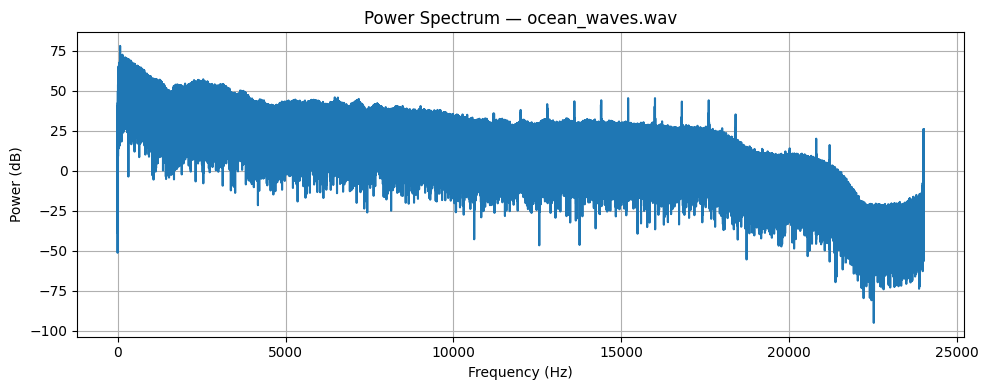

In [30]:
# Power spectrum plot
fft_vals = np.fft.rfft(file1)           # Real FFT (only positive frequencies)
power = np.abs(fft_vals) ** 2           # Power = magnitude squared
freqs = np.fft.rfftfreq(len(file1), d=1/sr)  # Frequency axis in Hz

# Plot
plt.figure(figsize=(10, 4))
plt.plot(freqs, 10 * np.log10(power))   # Convert to dB (log scale)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title(f'Power Spectrum — {filename1}')
plt.grid(True)
plt.tight_layout()
plt.show()

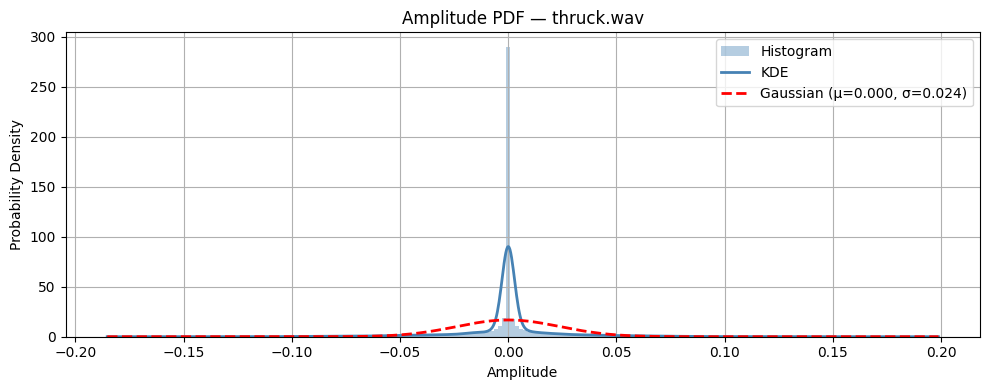

In [52]:
# Probability density function (PDF) plot with Gaussian curve printed on it
fig, ax = plt.subplots(figsize=(10, 4))

# Option 1: Histogram (normalized to density)
ax.hist(file1, bins=200, density=True, alpha=0.4, color='steelblue', label='Histogram')

# Option 2: Smooth KDE curve (kernel density estimate)
kde = gaussian_kde(file1)
x = np.linspace(file1.min(), file1.max(), 1000)
ax.plot(x, kde(x), color='steelblue', linewidth=2, label='KDE')

# Option 3: Overlay a true Gaussian for comparison
mu, sigma = file1.mean(), file1.std()
ax.plot(x, norm.pdf(x, mu, sigma), color='red', linewidth=2,
        linestyle='--', label=f'Gaussian (μ={mu:.3f}, σ={sigma:.3f})')

ax.set_xlabel('Amplitude')
ax.set_ylabel('Probability Density')
ax.set_title(f'Amplitude PDF — {filename1}')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [35]:
from utils.time_domain_utils import (
  plot_waveform,
  plot_waveform_with_line,
  amplitude_envelope,
  get_snr
)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'HVAC'}, xlabel='Time (sec)', ylabel='Amplitude'>)

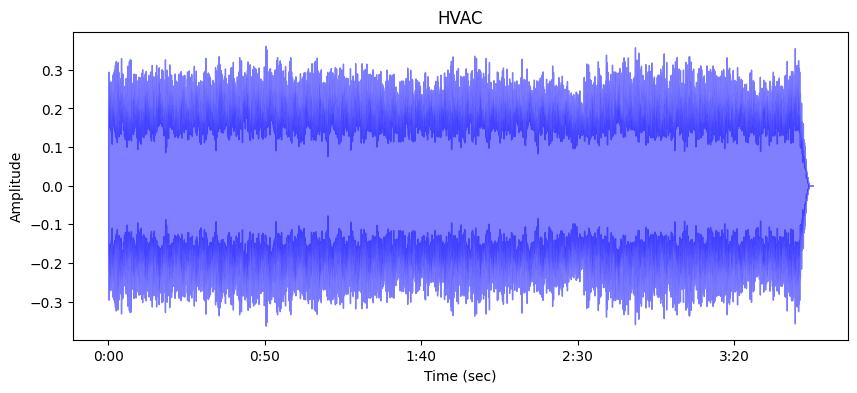

In [54]:
plot_waveform(file1, 'HVAC', sr)

In [39]:

snr = get_snr(filepath1)

In [40]:
snr

26.088809967041016

In [41]:
%pip install pyrnnoise

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 2.8 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 5.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
sr = 16000
filename = 'sheep'
input_file = f'../data/audio/{filename}.wav'
output_file = f'../data/audio/{filename}_prynnoise_cleaned.wav'

In [6]:
from pyrnnoise import RNNoise

ModuleNotFoundError: No module named 'av.option'

In [ ]:
# Create denoiser instance
denoiser = RNNoise(sample_rate=16000)

# Process audio file
for speech_prob in denoiser.denoise_wav("input.wav", "output.wav"):
    print(f"Processing frame with speech probability: {speech_prob}")

In [ ]:
#denoise input_file output_file --plot

SyntaxError: invalid syntax (3107727431.py, line 1)

In [ ]:
#denoise input.wav output.wav

In [7]:
%pip install --upgrade --force-reinstall av pyrnnoise

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
  Using cached https://nexus.cainc.com/repository/pypi/packages/av/17.1.0/av-17.1.0-cp311-abi3-macosx_14_0_arm64.whl (18.2 MB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/pyrnnoise/0.4.3/pyrnnoise-0.4.3-py3-none-macosx_15_0_universal2.whl (13.4 MB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/audiolab/0.5.1/audiolab-0.5.1-py3-none-any.whl (52 kB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/click/8.4.1/click-8.4.1-py3-none-any.whl (116 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 8.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 11.3 MB/s eta 0:00:00a 0:00:01
  Using cached https://nexus.cainc.com/repository/pypi/packages/humanize/4.15.0/humanize-4.15.0-py3-none-any.whl (132 kB)
  Using cached https://nexus.cainc.com/repository/pypi/packages/jinja2/3.1.6/jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached htt

In [6]:
from pyrnnoise import RNNoise

ModuleNotFoundError: No module named 'av.option'

In [7]:
%pip install "av==10.0.0" pyrnnoise

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.5 MB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [1 lines of output]
      pkg-config is required for building PyAV
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install nsnet2-denoiser

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 3.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 8.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
sr = 16000
filename1 = 'new_59s.wav'
filepath1 = f'../data/audio/{filename1}'

In [3]:
from nsnet2_denoiser import NSnet2Enhancer
enhancer = NSnet2Enhancer(fs=16000)

ImportError: cannot import name 'blackman' from 'scipy.signal' (/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/scipy/signal/__init__.py)

In [ ]:
# numpy
import soundfile as sf
sigIn, fs = sf.read("audio.wav")
outSig = enhancer(sigIn, fs)

# pcm_16le
from pydub import AudioSegment
audioIn = AudioSegment.from_wav("audio.wav")
audioOut = enhancer.pcm_16le(audioIn.raw_data)

In [4]:
%pip install av

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pyrnnoise import RNNoise

ModuleNotFoundError: No module named 'av.option'

In [2]:
%pip install "av==9.2.0"

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [1 lines of output]
      pkg-config is required for building PyAV
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install denoise-audio

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python ==3.10.*; 0.1.1 Requires-Python ==3.10.*; 0.1.2 Requires-Python ==3.10.*
ERROR: Could not find a version that satisfies the requirement denoise-audio (from versions: none)

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for denoise-audio
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install hpss-voice-denoiser

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from hpss_denoiser import HPSSDenoiser

In [2]:
%pip install pywebrtc-audio

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pywebrtc_audio import AudioProcessor

In [2]:
%pip install torch torchaudio --index-url https://download.pytorch.org/whl/cpu
%pip install deepfilternet

Looking in indexes: https://download.pytorch.org/whl/cpu

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [6 lines of output]
      Checking for Rust toolchain....
      
      Cargo, the Rust package manager, is not installed or is not on PATH.
      This package requires Rust and Cargo to compile extensions. Install it through
      the system's package manager or via https://rustup.rs/
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of p

In [4]:
from df.enhance import enhance, init_df
import soundfile as sf

ModuleNotFoundError: No module named 'df'

In [5]:
%pip install noisereduce

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from scipy.io import wavfile
import noisereduce as nr

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
sr = 16000
filename = 'bridge_birdsong'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce.wav'


In [ ]:
# load data
rate, data = wavfile.read(input_filepath)
# perform noise reduction
reduced_noise = nr.reduce_noise(y=data, sr=rate)
wavfile.write(output_filepath, rate, reduced_noise)

# Weird results where it worked fast and was helpful for some of hte hvac noise, but
# program kept going (never finished) for ones with birdsong or motorcycle engine in the background
# did keyboard interrput after 60s
# not very helpful with babble either, sometimes it muted the kid and retained the babble

'''
bridge_hvac_louder_noisereduce
bridge_desktop_computer_noisereduce
bridge_hvac_loudest_noisereduce
new_59s_noisereduce —> babble, did not go well
sheep_noisereduce —> helped, still babble in background but reduced the other types of noise
bridge_birdsong —> never finished
'''

KeyboardInterrupt: 

In [31]:
rate, data = wavfile.read(input_filepath)
# perform noise reduction
reduced_noise = nr.reduce_noise(y=data, sr=rate, stationary=True)
wavfile.write(output_filepath, rate, reduced_noise)

/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:1430: UserWarning: nperseg = 1024 is greater than input length  = 2, using nperseg = 2
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


ValueError: noverlap must be less than nperseg.

In [ ]:
## seems to work

# load data
rate, data = wavfile.read(input_filepath)
print(rate)

# Convert to float32 to avoid integer overflow issues
data_float = data.astype(np.float32) / np.iinfo(data.dtype).max

if data_float.ndim == 2:
    data_float = data_float.mean(axis=1)

reduced = nr.reduce_noise(
    y=data_float,
    #y=data,
    sr=rate,
    stationary=True,        # fast; avoids the nonstationary blowup
    # prop_decrease=0.75,     # less aggressive, preserves more speech
    # n_fft=512,              # smaller FFT = faster
)

# Convert back and save
#reduced_int = (reduced * np.iinfo(np.int16.max).max).astype(np.int16)
wavfile.write(output_filepath, rate, reduced)

16000


In [32]:
import noisereduce
print(noisereduce.__version__)
print(f"rate: {rate}, dtype: {data.dtype}, shape: {data.shape}")

AttributeError: module 'noisereduce' has no attribute '__version__'

In [42]:
## seems to work


filename = 'cats_59s'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce.wav'

# load data
rate, data = wavfile.read(input_filepath)
print(rate)

# Convert to float32 to avoid integer overflow issues
# data_float = data.astype(np.float32) / np.iinfo(data.dtype).max

# avoid it being stereo
if data.ndim == 2:
    data = data.mean(axis=1)

reduced = nr.reduce_noise(
    y=data,
    sr=rate,
    stationary=True,        # fast; avoids the nonstationary blowup
    # prop_decrease=0.75,     # less aggressive, preserves more speech
    # n_fft=512,              # smaller FFT = faster
)

# Convert back and save
#reduced_int = (reduced * np.iinfo(np.int16.max).max).astype(np.int16)
wavfile.write(output_filepath, rate, reduced)

16000


In [43]:
from utils.frequency_domain_utils import (
  reduce_stationary_noise,
)

16000


In [52]:
# works best with SR=16000, and for files with SNR < 0
# does not cut out babble but will cut out stationary noise
def reduce_stationary_noise2(input_filepath, output_filepath):
    # load data
    rate, data = wavfile.read(input_filepath)

    # convert to mono if stereo
    if data.ndim == 2:
        data = data.mean(axis=1)

    orig_dtype = data.dtype
    # normalize to float32 [-1.0, 1.0] only if integer dtype
    if np.issubdtype(data.dtype, np.integer):
        data_float = data.astype(np.float32) / np.iinfo(data.dtype).max
        is_int = True
    else:
        data_float = data.astype(np.float32)
        is_int = False

    reduced = nr.reduce_noise(
        y=data_float,
        sr=rate,
        stationary=True,        # fast; avoids the nonstationary blowup
        # prop_decrease=0.75,     # less aggressive, preserves more speech
        # n_fft=512,              # smaller FFT = faster
    )

    # clip to prevent any overflow, convert back to original int dtype
    # reduced = np.clip(reduced, -1.0, 1.0)
    # reduced_int = (reduced * np.iinfo(orig_dtype).max).astype(orig_dtype)

    reduced = np.clip(reduced, -1.0, 1.0)

    if is_int:
        out = (reduced * np.iinfo(orig_dtype).max).astype(orig_dtype)
    else:
        out = reduced.astype(np.float32)

    wavfile.write(output_filepath, rate, out)

In [53]:
filename = 'bridge_motorcycle_engine'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce.wav'
reduce_stationary_noise2(input_filepath, output_filepath)

In [54]:
def reduce_stationary_noise3(input_filepath, output_filepath):
    rate, data = wavfile.read(input_filepath)

    if data.ndim == 2:
        data = data.mean(axis=1)

    print(f"dtype: {data.dtype}")
    print(f"input  min/max: {data.min():.4f} / {data.max():.4f}")

    orig_dtype = data.dtype
    if np.issubdtype(data.dtype, np.integer):
        data_float = data.astype(np.float32) / np.iinfo(data.dtype).max
        is_int = True
    else:
        data_float = data.astype(np.float32)
        is_int = False

    print(f"float  min/max: {data_float.min():.4f} / {data_float.max():.4f}")

    reduced = nr.reduce_noise(y=data_float, sr=rate, stationary=True)

    print(f"reduced min/max: {reduced.min():.4f} / {reduced.max():.4f}")

    reduced = np.clip(reduced, -1.0, 1.0)

    if is_int:
        out = (reduced * np.iinfo(orig_dtype).max).astype(orig_dtype)
    else:
        out = reduced.astype(np.float32)

    print(f"output min/max: {out.min():.4f} / {out.max():.4f}")

    wavfile.write(output_filepath, rate, out)

In [126]:
filename = 'bridge_hvac_medium'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce.wav'
reduce_stationary_noise3(input_filepath, output_filepath)

dtype: int16
input  min/max: -20788.0000 / 19438.0000
float  min/max: -0.6344 / 0.5932
reduced min/max: -0.2466 / 0.2310
output min/max: -8081.0000 / 7569.0000


In [61]:
def reduce_stationary_noise4(input_filepath, output_filepath):
    rate, data = wavfile.read(input_filepath)

    if data.ndim == 2:
        data = data.mean(axis=1)

    data_float = data.astype(np.float32)

    # normalize to [-1.0, 1.0] based on actual range, not dtype
    max_val = np.abs(data_float).max()
    if max_val > 1.0:
        data_float = data_float / max_val

    reduced = nr.reduce_noise(y=data_float, sr=rate, stationary=True)

    reduced = np.clip(reduced, -1.0, 1.0)

    # convert back to bit depth int16
    out = (reduced * 32767).astype(np.int16)

    # write as float32 wav (universally supported)
    wavfile.write(output_filepath, rate, out)

In [62]:
filename = 'bridge_motorcycle_engine'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce2.wav'
reduce_stationary_noise4(input_filepath, output_filepath)

In [ ]:
filename = 'bridge_motorcycle_engine'
input_filepath = f'../data/audio/{filename}.wav'
output_filepath = f'../data/audio/{filename}_noisereduce.wav'
reduce_stationary_noise2(input_filepath, output_filepath)

wavfile.read

## Ways to import audio

In [ ]:
filename = 'bridge_motorcycle_engine'
input_filepath = f'../data/audio/{filename}.wav'


In [94]:
from scipy.io import wavfile
import math

In [108]:
rate, data = wavfile.read(input_filepath)
all_numbers = data.flatten()
channels = 1 if data.ndim == 1 else data.shape[1]

print(input_filepath)
print(f'sampling rate: {rate}')
print(f'data: {data}')
print()
print(f'data.shape: {data.shape}')
print(f'channels:       {channels}')
print(f'data.dtype: {data.dtype}')
print(f'duration:       {data.shape[0] / rate:.2f} seconds')
print(f'max:            {all_numbers.max():.4f}')
print(f'min:            {all_numbers.min():.4f}')
print(f'mean (DC offset):      {all_numbers.mean():.6f}')


../data/audio/827530__yevgverh__ocean_coast_04_092025_0659am.wav
sampling rate: 48000
data: [[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]

data.shape: (8696704, 2)
channels:       2
data.dtype: int16
duration:       181.18 seconds
max:            24147.0000
min:            -21924.0000
mean (DC offset):      0.000044


In [120]:
#filename = 'bridge_motorcycle_engine'
filename = '70152__justinbw__desktop-computer-position-2'
input_filepath = f'../data/audio/{filename}.wav'

In [121]:
# https://python-soundfile.readthedocs.io/en/latest/
import soundfile as sf
audio, sr = sf.read(input_filepath)
print(sr)
show_array_info(audio)

44100
data: [ 0.00056958 -0.00072706  0.00102103 ... -0.00903714 -0.00281441
  0.0016197 ]

data.shape: (607534,)
channels:       1
data.dtype: float64
max:            0.2197
min:            -0.2124
mean (DC offset):      -0.000132


In [122]:
from scipy.io import wavfile
sr, audio = wavfile.read(input_filepath)
print(sr)
show_array_info(audio)

44100
data: [  1223168  -1561344   2192640 ... -19407104  -6043904   3478272]

data.shape: (607534,)
channels:       1
data.dtype: int32
max:            471850240.0000
min:            -456080640.0000
mean (DC offset):      -284242.362074


In [124]:
import librosa
# Librosa.load automatically resamples at sr=22050
audio, sr = librosa.load(input_filepath)
print(sr)
show_array_info(audio)

22050
data: [-0.00020837  0.00120385  0.00061296 ... -0.01929741 -0.01359687
 -0.00271416]

data.shape: (303767,)
channels:       1
data.dtype: float32
max:            0.2200
min:            -0.2118
mean (DC offset):      -0.000132


In [110]:


from utils.time_domain_utils import (
  show_array_info,
  show_audio_info
)

## denoise-audio

In [125]:
%pip install denoise-audio

Looking in indexes: https://nexus.cainc.com/repository/pypi/simple
ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python ==3.10.*; 0.1.1 Requires-Python ==3.10.*; 0.1.2 Requires-Python ==3.10.*
ERROR: Could not find a version that satisfies the requirement denoise-audio (from versions: none)

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for denoise-audio
Note: you may need to restart the kernel to use updated packages.
